# Dynamic Model in Levels

In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data2 import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "output_dynamic_level_model_v01"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [2]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../data/{dataframe_name}_val.zip")

columns_to_drop = [
    "Q_t-2",
    "P_bb_t-2",
    "REVIEW_COUNT_t-2",
    "RATING_t-2",
    "pred_ml_l_lag_1",
    "pred_ml_m_lag_1",
]


df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'REVIEW_COUNT_t-1', 'RATING_t-1', 'Delta_Q_t', 'Delta_P_bb_t',
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=342)

In [3]:
print(dataframe_name)

dataset_txt_only_False_embeddings_True


In [4]:
print(df_full_val.shape)
print(df_full_train.shape)

(38041, 342)
(38146, 342)


In [5]:
df_full_val[["ASIN", "date"]].to_csv("main_val_keys.csv", index=False)
df_full_train[["ASIN", "date"]].to_csv("main_train_keys.csv", index=False)

In [6]:
df_full_val.isna().sum()

ASIN                    0
date                    0
index                   0
Q_t                     0
PRICE                   0
                       ..
pred_ml_m               0
pred_ml_l_diff          0
pred_ml_m_diff          0
pred_ml_l_diff_lag_1    0
pred_ml_m_diff_lag_1    0
Length: 342, dtype: int64

In [7]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [8]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [9]:
df_full_train["ASIN"].nunique()

3717

In [10]:
df_full_val["ASIN"].nunique()

3708

In [11]:
from datetime import datetime

date_objects = [datetime.strptime(date, "%Y-%m-%d") for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [
    (date_objects[i + 1] - date_objects[i]).days for i in range(len(date_objects) - 1)
]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [12]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_pca = ["pca_0", "pca_1", "pca_2", "pca_3", "pca_4"]
controls_similarities = [
    "similarity_cluster_0",
    "similarity_cluster_1",
    "similarity_cluster_2",
    "similarity_cluster_3",
    "similarity_cluster_4",
]

embeddings = [f"emb_{i}" for i in range(256)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = cont_controls + dummy_controls

## Interactions & CATE Basis

In [13]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1,
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,0.305280,0.463601,-0.461880,0.463422,0.457113,-0.620049,-0.080700
1,1.0,0.272505,0.653600,-0.461880,0.463422,0.457113,-0.620049,-0.080700
2,1.0,0.036240,0.687961,-0.461695,0.459950,0.457477,-0.622177,-0.072107
3,1.0,0.025283,0.636881,-0.461695,0.459950,0.457477,-0.622177,-0.072107
4,1.0,-0.051370,0.556816,-0.461695,0.459950,0.457477,-0.622177,-0.072107


In [14]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val, df_basis=df_basis, cols_to_interact=["Q_t-1", "P_bb_t-1"]
)

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_similarity_cluster_0', 'interaction_Q_t-1_similarity_cluster_1', 'interaction_Q_t-1_similarity_cluster_2', 'interaction_Q_t-1_similarity_cluster_3', 'interaction_Q_t-1_similarity_cluster_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_similarity_cluster_0', 'interaction_P_bb_t-1_similarity_cluster_1', 'interaction_P_bb_t-1_similarity_cluster_2', 'interaction_P_bb_t-1_similarity_cluster_3', 'interaction_P_bb_t-1_similarity_cluster_4']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'interaction_Q_t-1_similarity_cluster_3',
       'interaction_Q_t-1_similarity_cluster_4',
       'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1',
       'interaction_P_bb_t-1_P_bb_t-1',
       'interaction_P_bb_t-1_similarity_cluster_0',
       'interaction_P_bb_t-1_similarity_cluster_1',
       'interaction_P_bb_t-1_similarity_cluster_2',
       'interaction_P_bb_t-1_similarity_cluster_3',
       'interaction_P_bb_t-1_similarity_cluster_4'],
      dtype='object', length=358)

## Average Effect

In [15]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [16]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [17]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0027
          coef  std err        t  P>|t|   [5.0%  95.0%]
const  -10.756    0.104 -103.858  0.000 -10.926 -10.586
P_bb_t  -0.111    0.033   -3.384  0.001  -0.164  -0.057


,lower,upper,coef
P_bb_t,-0.164462,-0.056884,-0.110673


In [18]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8835
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.677    0.034  -19.935    0.0 -0.733  -0.621
P_bb_t   -0.690    0.040  -17.248    0.0 -0.756  -0.624
Q_t-1     0.936    0.003  321.411    0.0  0.931   0.941
P_bb_t-1  0.678    0.040   16.995    0.0  0.613   0.744


In [19]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8884
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -1.346    0.060  -22.322  0.000 -1.445  -1.247
P_bb_t   -0.657    0.040  -16.626  0.000 -0.722  -0.592
Q_t-1     0.862    0.005  157.814  0.000  0.853   0.871
P_bb_t-1  0.600    0.039   15.305  0.000  0.536   0.665
emb_0     0.195    0.123    1.591  0.112 -0.007   0.397
...         ...      ...      ...    ...    ...     ...
emb_251   0.027    0.109    0.251  0.802 -0.152   0.207
emb_252   0.185    0.111    1.669  0.095  0.003   0.366
emb_253   0.054    0.100    0.534  0.593 -0.111   0.219
emb_254  -0.104    0.093   -1.120  0.263 -0.258   0.049
emb_255  -0.349    0.102   -3.427  0.001 -0.517  -0.182

[260 rows x 6 columns]


In [20]:
ci_linear_base_lagged_add_controls = estimate_linear_model(
    controls=lag_1_vars + additional_controls
)

Adjusted R^2: 0.8929
                                           coef  std err        t  P>|t|  \
const                                    -0.962    0.051  -18.978  0.000   
P_bb_t                                   -0.746    0.039  -18.956  0.000   
Q_t-1                                     0.925    0.003  279.493  0.000   
P_bb_t-1                                  0.722    0.039   18.383  0.000   
RATING_t-1                                0.030    0.007    4.621  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    8.670  0.000   
New Offer Count: Current                 -0.001    0.001   -1.625  0.104   
Count of retrieved live offers: New, FBA  0.005    0.001    3.398  0.001   
Count of retrieved live offers: New, FBM -0.004    0.001   -3.797  0.000   
Cars & Race Cars                          0.020    0.006    3.371  0.001   
Trains & Trams                            0.052    0.014    3.754  0.000   
Train Sets                                0.032    0.008    4.069  

In [21]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(
    controls=lag_1_vars + additional_controls + embeddings
)

Adjusted R^2: 0.8968
             coef  std err        t  P>|t|  [5.0%  95.0%]
const      -1.541    0.072  -21.359  0.000 -1.660  -1.422
P_bb_t     -0.712    0.039  -18.364  0.000 -0.776  -0.649
Q_t-1       0.858    0.006  152.447  0.000  0.849   0.868
P_bb_t-1    0.654    0.039   16.937  0.000  0.591   0.718
RATING_t-1  0.029    0.007    3.852  0.000  0.016   0.041
...           ...      ...      ...    ...    ...     ...
emb_251     0.066    0.107    0.618  0.537 -0.110   0.241
emb_252     0.111    0.109    1.020  0.308 -0.068   0.290
emb_253     0.118    0.100    1.188  0.235 -0.045   0.282
emb_254    -0.058    0.092   -0.630  0.529 -0.209   0.093
emb_255    -0.329    0.099   -3.330  0.001 -0.492  -0.167

[288 rows x 6 columns]


In [22]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.8959
                                           coef  std err        t  P>|t|  \
const                                    -1.400    0.066  -21.088  0.000   
P_bb_t                                   -0.723    0.039  -18.725  0.000   
Q_t-1                                     0.878    0.005  167.971  0.000   
P_bb_t-1                                  0.680    0.038   17.699  0.000   
similarity_cluster_0                     -0.136    0.094   -1.446  0.148   
similarity_cluster_1                     -0.570    0.112   -5.109  0.000   
similarity_cluster_2                     -0.958    0.198   -4.840  0.000   
similarity_cluster_3                     -1.115    0.225   -4.953  0.000   
similarity_cluster_4                     -0.499    0.086   -5.821  0.000   
RATING_t-1                                0.024    0.007    3.648  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    9.364  0.000   
New Offer Count: Current                  0.000    0.001    0.076  

In [23]:
ci_linear_interactions = estimate_linear_model(
    controls=interaction_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.8964
                                             coef  std err       t  P>|t|  \
const                                      -1.942    0.480  -4.043  0.000   
P_bb_t                                     -0.727    0.039 -18.698  0.000   
interaction_Q_t-1_intercept                 0.595    0.042  14.033  0.000   
interaction_Q_t-1_Q_t-1                    -0.010    0.005  -2.093  0.036   
interaction_Q_t-1_P_bb_t-1                 -0.048    0.002 -21.256  0.000   
interaction_Q_t-1_similarity_cluster_0      0.467    0.140   3.330  0.001   
interaction_Q_t-1_similarity_cluster_1     -0.320    0.126  -2.549  0.011   
interaction_Q_t-1_similarity_cluster_2     -1.529    0.334  -4.584  0.000   
interaction_Q_t-1_similarity_cluster_3     -1.664    0.370  -4.497  0.000   
interaction_Q_t-1_similarity_cluster_4     -0.386    0.099  -3.887  0.000   
interaction_P_bb_t-1_intercept             -0.149    0.012 -12.260  0.000   
interaction_P_bb_t-1_Q_t-1                  0.087    0.

In [24]:
ci_linear_base_lagged["model"] = "Linear lagged"
ci_linear_embeddings["model"] = "Linear lagged_and_embeddings"
ci_linear_base_lagged_add_controls["model"] = "Linear lagged_and_add_controls"
ci_linear_base_lagged_add_controls_emb["model"] = (
    "Linear lagged_and_add_controls_and_emb"
)
ci_linear_base_lagged_add_controls_sim["model"] = (
    "Linear lagged_and_add_controls_and_sim"
)
ci_linear_interactions["model"] = "Linear interactions"

df_base = pd.concat(
    [
        ci_linear_base_lagged,
        ci_linear_embeddings,
        ci_linear_base_lagged_add_controls,
        ci_linear_base_lagged_add_controls_emb,
        ci_linear_base_lagged_add_controls_sim,
    ],
    ignore_index=True,
)

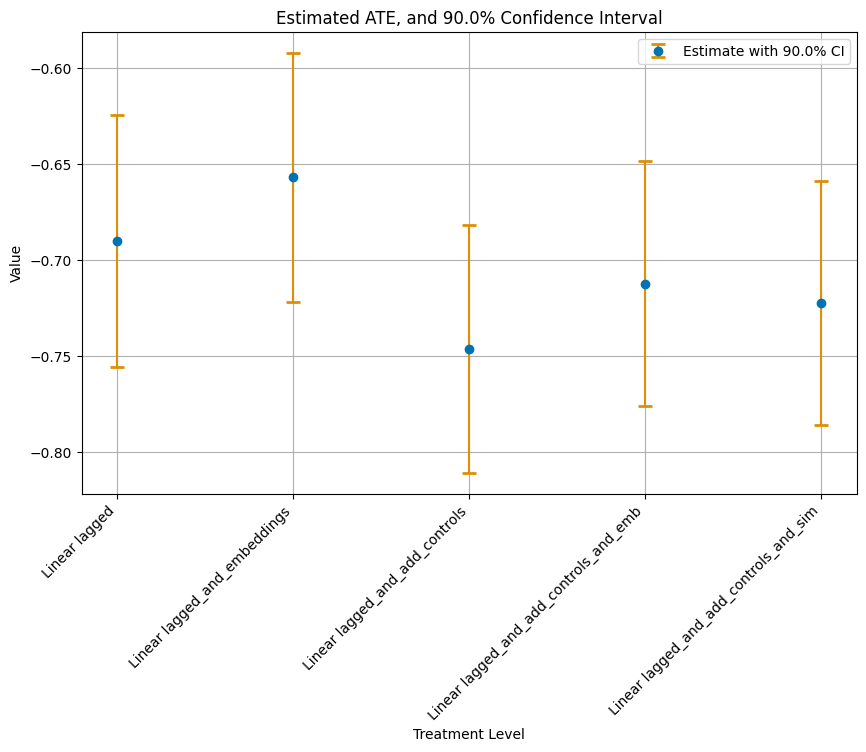

In [25]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_base["model"],
    df_base["coef"],
    yerr=[df_base["coef"] - df_base["lower"], df_base["upper"] - df_base["coef"]],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"linear_ate_estimates.png"))
plt.show()

In [26]:
df_base

,lower,upper,coef,model
0,-0.756093,-0.624438,-0.690266,Linear lagged
1,-0.721957,-0.591964,-0.656960,Linear lagged_and_embeddings
2,-0.811127,-0.681600,-0.746364,Linear lagged_and_add_controls
3,-0.776161,-0.648547,-0.712354,Linear lagged_and_add_controls_and_emb
4,-0.786005,-0.659069,-0.722537,Linear lagged_and_add_controls_and_sim


### DML Models

In [27]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)


def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])


def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN",
    )

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ["coef"]]
    ci_tab_dml.columns = ["lower", "upper", "coef"]

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(
        f"R2 Outcome: {round(r2_scores['ml_l'][0, 0], 4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0], 4)}\n"
    )

    return tab_dml_obj, ci_tab_dml

In [28]:
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(
    controls=lag_1_vars + embeddings
)

C:\Users\Work\AppData\Local\Temp\ipykernel_24944\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.623    0.049 -12.632    0.0 -0.704 -0.542
R2 Outcome: 0.8636 R2 Treatment: 0.9731



In [29]:
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(
    controls=lag_1_vars + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_24944\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

        coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.69    0.041 -16.812    0.0 -0.758 -0.623
R2 Outcome: 0.8991 R2 Treatment: 0.9775



In [30]:
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = (
    estimate_dml_model(controls=lag_1_vars + embeddings + additional_controls)
)

C:\Users\Work\AppData\Local\Temp\ipykernel_24944\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.697    0.049 -14.362    0.0 -0.777 -0.617
R2 Outcome: 0.891 R2 Treatment: 0.9744



In [31]:
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_24944\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.691    0.041 -17.051    0.0 -0.757 -0.624
R2 Outcome: 0.9009 R2 Treatment: 0.9774



In [32]:
tab_dml_obj_pca_add_controls, ci_tab_dml_pca_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_pca + additional_controls
)

C:\Users\Work\AppData\Local\Temp\ipykernel_24944\1824383861.py:11: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor 

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.677    0.044 -15.416    0.0 -0.749 -0.605
R2 Outcome: 0.8987 R2 Treatment: 0.9768



### Visualization

In [33]:
ci_tab_dml_embeddings["model"] = "plr_embeddings"
ci_tab_dml_add_controls["model"] = "plr_add_controls"
ci_tab_dml_embeddings_add_controls["model"] = "plr_embeddings_add_controls"
ci_tab_dml_sim_add_controls["model"] = "plr_sim_add_controls"
ci_tab_dml_pca_add_controls["model"] = "plr_pca_add_controls"


df_averages = pd.concat(
    [
        ci_tab_dml_embeddings,
        ci_tab_dml_add_controls,
        ci_tab_dml_embeddings_add_controls,
        ci_tab_dml_sim_add_controls,
        ci_tab_dml_pca_add_controls,
    ],
    ignore_index=True,
)

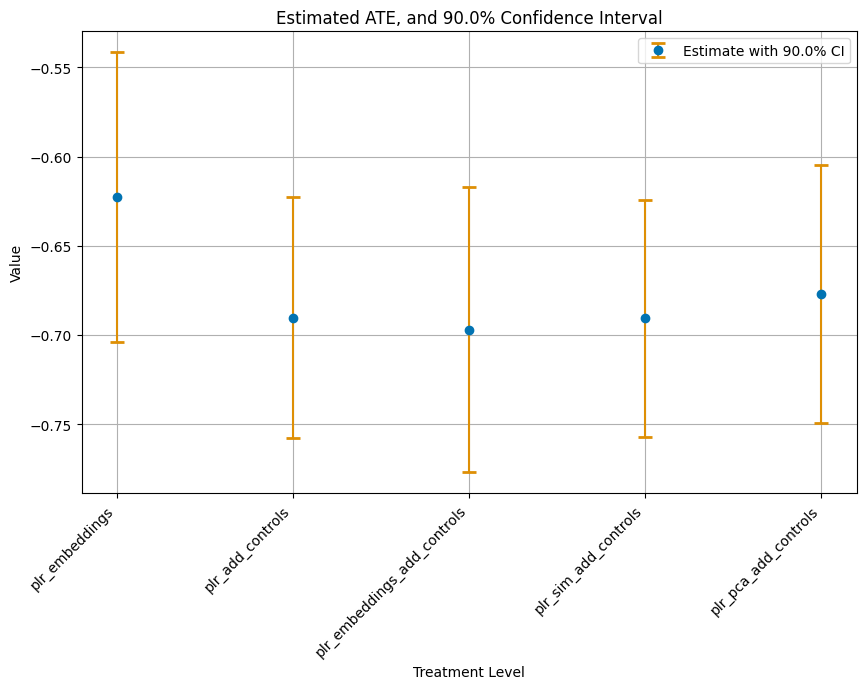

In [34]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_averages["model"],
    df_averages["coef"],
    yerr=[
        df_averages["coef"] - df_averages["lower"],
        df_averages["upper"] - df_averages["coef"],
    ],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"plr_ate_estimates.png"))
plt.show()

## GATEs

0
similarity_cluster_0    6942
similarity_cluster_1    9966
similarity_cluster_2    8285
similarity_cluster_3    8701
similarity_cluster_4    4147
dtype: int64


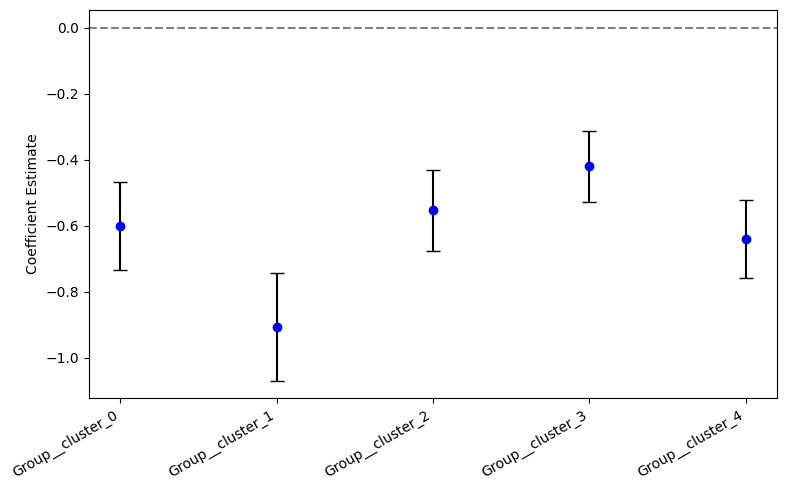

In [35]:
groups = pd.DataFrame(
    df_dynamic[
        [
            "similarity_cluster_0",
            "similarity_cluster_1",
            "similarity_cluster_2",
            "similarity_cluster_3",
            "similarity_cluster_4",
        ]
    ].idxmax(axis=1)
)

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt="o",
    capsize=5,
    color="blue",
    ecolor="black",
)

# Draw a zero line for reference
plt.axhline(y=0, color="gray", linestyle="--")

# Customizing x-axis labels
plt.xticks(
    ticks=x_vals,
    labels=[gr.replace("similarity", "") for gr in gates_0_summ.index],
    rotation=30,
    ha="right",
)
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs

In [36]:
uniform_ci = True  # False | True

In [37]:
cate_controls = lag_1_vars + embeddings + additional_controls
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls

In [38]:
cate_kwargs_val = {"cov_type": "cluster", "cov_kwds": {"groups": df_dynamic["ASIN"]}}

cate_models_polynomial = {
    "Linear Specification": None,
    "Linear Specification (Interactions)": None,
    "PLR Specification": None,
}

# Linear Models
cate_models_polynomial["Linear Specification"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(
    cate_models_polynomial["Linear Specification"], level=confidence_level
)
print("=" * 80)  #

cate_models_polynomial["Linear Specification (Interactions)"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(
    cate_models_polynomial["Linear Specification (Interactions)"],
    level=confidence_level,
)
print("=" * 80)

# tabular DML model
cate_models_polynomial["PLR Specification"] = plr_obj.cate(df_basis, **cate_kwargs_val)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial["PLR Specification"].blp_model, level=confidence_level
)
print("=" * 80)


Linear Specification
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.693    0.039 -17.805  0.000  -0.757 -0.629
Q_t-1                -0.165    0.055  -2.986  0.003  -0.256 -0.074
P_bb_t-1             -0.014    0.050  -0.285  0.776  -0.097  0.068
similarity_cluster_0 -0.139    1.546  -0.090  0.928  -2.683  2.404
similarity_cluster_1 -2.881    1.653  -1.743  0.081  -5.600 -0.162
similarity_cluster_2 -3.595    3.052  -1.178  0.239  -8.615  1.426
similarity_cluster_3 -4.459    3.395  -1.314  0.189 -10.044  1.125
similarity_cluster_4 -2.245    1.112  -2.019  0.044  -4.074 -0.416

Linear specification with interactions
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.703    0.039 -18.006  0.000  -0.768 -0.639
Q_t-1                -0.186    0.055  -3.362  0.001  -0.278 -0.095
P_bb_t-1             -0.025    0.051  -0.490  0.624  -0.110  0.059
similarity_cluster_0  0.134    1.554   0.086  0.931  -2.423  2.691


In [39]:
cate_models_polynomial["Linear Specification (Interactions)"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.025
Method:                 Least Squares   F-statistic:                              51.12
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    6.02e-79
Time:                        13:24:13   Log-Likelihood:                         -20981.
No. Observations:               38041   AIC:                                  4.198e+04
Df Residuals:                   38033   BIC:                                  4.205e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.7033      0.039    -18.006      0.000      -0.780      -0.627
Q_t-1                   -0.1865      0.055     -3.362      0.001      -0.295      -0.078
P_bb_t-1                -0.0251      0.051     -0.490      0.624      -0.126       0.075
similarity_cluster_0     0.1337      1.554      0.086      0.931      -2.913       3.180
similarity_cluster_1    -2.6552      1.682     -1.579      0.114      -5.951       0.641
similarity_cluster_2    -3.8265      3.060     -1.250      0.211      -9.824       2.171
similarity_cluster_3    -4.6717      3.405     -1.372      0.170     -11.346       2.003
similarity_cluster_4    -2.2135      1.126     -1.965      0.049      -4.421      -0.006
==============================================================================
Omnibus:                    12065.225   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           704593.441
Skew:                           0.713   Prob(JB):                         0.00
Kurtosis:                      24.036   Cond. No.                         174.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [40]:
cate_models_polynomial["PLR Specification"].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):              0.032
Method:                 Least Squares   F-statistic:                              45.90
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                    7.31e-71
Time:                        13:24:13   Log-Likelihood:                         -21680.
No. Observations:               38041   AIC:                                  4.338e+04
Df Residuals:                   38033   BIC:                                  4.345e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.7358      0.046    -15.860      0.000      -0.827      -0.645
Q_t-1                   -0.3248      0.092     -3.515      0.000      -0.506      -0.144
P_bb_t-1                -0.0488      0.035     -1.401      0.161      -0.117       0.019
similarity_cluster_0    -2.3123      1.524     -1.517      0.129      -5.300       0.675
similarity_cluster_1    -7.3655      1.831     -4.023      0.000     -10.954      -3.777
similarity_cluster_2    -6.7850      3.558     -1.907      0.056     -13.758       0.188
similarity_cluster_3    -8.2553      3.985     -2.072      0.038     -16.066      -0.445
similarity_cluster_4    -4.5594      1.303     -3.500      0.000      -7.113      -2.006
==============================================================================
Omnibus:                    14871.916   Durbin-Watson:                   1.543
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           527409.889
Skew:                           1.221   Prob(JB):                         0.00
Kurtosis:                      21.077   Cond. No.                         296.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [41]:
df_full_train[[v for v in df_full_train.columns if "sim" in v]].corr()

,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
similarity_cluster_0,1.000000,-0.980078,0.203170,0.161337,0.649355
similarity_cluster_1,-0.980078,1.000000,-0.282031,-0.062151,-0.771834
similarity_cluster_2,0.203170,-0.282031,1.000000,-0.929894,0.675200
similarity_cluster_3,0.161337,-0.062151,-0.929894,1.000000,-0.482451
similarity_cluster_4,0.649355,-0.771834,0.675200,-0.482451,1.000000


In [42]:
df_full_val[[v for v in df_full_val.columns if "sim" in v]].corr()

,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
similarity_cluster_0,1.000000,-0.978694,0.180374,0.176175,0.656100
similarity_cluster_1,-0.978694,1.000000,-0.232252,-0.100654,-0.779944
similarity_cluster_2,0.180374,-0.232252,1.000000,-0.931916,0.587191
similarity_cluster_3,0.176175,-0.100654,-0.931916,1.000000,-0.404359
similarity_cluster_4,0.656100,-0.779944,0.587191,-0.404359,1.000000


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def vif(df_sim):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_sim.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_sim.values, i) for i in range(len(df_sim.columns))
    ]
    print(vif_data)

In [44]:
vif(df_full_train[[v for v in df_full_train.columns if "sim" in v]])

                feature          VIF
0  similarity_cluster_0   270.564273
1  similarity_cluster_1   388.486416
2  similarity_cluster_2  1199.329567
3  similarity_cluster_3  1500.178520
4  similarity_cluster_4   120.796741


In [45]:
vif(df_full_val[[v for v in df_full_val.columns if "sim" in v]])

                feature          VIF
0  similarity_cluster_0   273.034388
1  similarity_cluster_1   364.765471
2  similarity_cluster_2  1282.458707
3  similarity_cluster_3  1586.946062
4  similarity_cluster_4   118.703391


In [46]:
vif(df_full_train[[v for v in df_full_train.columns if "pca" in v]])

  feature       VIF
0   pca_0  1.010479
1   pca_1  1.221580
2   pca_2  1.014006
3   pca_3  1.012787
4   pca_4  1.224618


In [47]:
vif(df_full_val[[v for v in df_full_val.columns if "pca" in v]])

  feature       VIF
0   pca_0  1.014833
1   pca_1  1.233070
2   pca_2  1.016776
3   pca_3  1.022637
4   pca_4  1.242613


In [48]:
latex_args = {
    "index": True,
    "float_format": "%.3f",
    "column_format": "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.693 & 0.039 & -17.805 & 0.000 & -0.757 & -0.629 \\
Q_t-1 & -0.165 & 0.055 & -2.986 & 0.003 & -0.256 & -0.074 \\
P_bb_t-1 & -0.014 & 0.050 & -0.285 & 0.776 & -0.097 & 0.068 \\
similarity_cluster_0 & -0.139 & 1.546 & -0.090 & 0.928 & -2.683 & 2.404 \\
similarity_cluster_1 & -2.881 & 1.653 & -1.743 & 0.081 & -5.600 & -0.162 \\
similarity_cluster_2 & -3.595 & 3.052 & -1.178 & 0.239 & -8.615 & 1.426 \\
similarity_cluster_3 & -4.459 & 3.395 & -1.314 & 0.189 & -10.044 & 1.125 \\
similarity_cluster_4 & -2.245 & 1.112 & -2.019 & 0.044 & -4.074 & -0.416 \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.703 & 0.039 & -18.006 & 0.000 & -0.768 & -0.639 \\
Q_t-1 & -0.186 & 0.055 & -3.362 & 0.001 & -0.278 & -0.095 \\
P_bb_t-1 & -0.025 & 0.051 & -0.490 & 0.624 & -0.110 & 0.059 \\
similarity_cluster_0 & 0.134 & 1.

In [49]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.693    0.039 -17.805  0.000  -0.757 -0.629
Q_t-1                -0.165    0.055  -2.986  0.003  -0.256 -0.074
P_bb_t-1             -0.014    0.050  -0.285  0.776  -0.097  0.068
similarity_cluster_0 -0.139    1.546  -0.090  0.928  -2.683  2.404
similarity_cluster_1 -2.881    1.653  -1.743  0.081  -5.600 -0.162
similarity_cluster_2 -3.595    3.052  -1.178  0.239  -8.615  1.426
similarity_cluster_3 -4.459    3.395  -1.314  0.189 -10.044  1.125
similarity_cluster_4 -2.245    1.112  -2.019  0.044  -4.074 -0.416
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.703    0.039 -18.006  0.000  -0.768 -0.639
Q_t-1                -0.186    0.055  -3.362  0.001  -0.278 -0.095
P_bb_t-1             -0.025    0.051  -0.490  0.624  -0.110  0.059
similarity_cluster_0  0.134    1.554   0.086  0.931  -2.423  2.691
similarity_cluster_1 -2.655    1.682  -1.579  0.114  -5.421  0

In [50]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.692672,0.038904,-0.756664,-0.628680
1,Linear Specification,Q_t-1,-0.165293,0.055356,-0.256346,-0.074241
2,Linear Specification,P_bb_t-1,-0.014324,0.050290,-0.097043,0.068396
3,Linear Specification,similarity_cluster_0,-0.139450,1.546406,-2.683062,2.404161
4,Linear Specification,similarity_cluster_1,-2.881275,1.653033,-5.600272,-0.162278
5,Linear Specification,similarity_cluster_2,-3.594823,3.052160,-8.615179,1.425533
6,Linear Specification,similarity_cluster_3,-4.459442,3.395056,-10.043812,1.124928
7,Linear Specification,similarity_cluster_4,-2.244834,1.111967,-4.073857,-0.415811
8,Linear Specification (Interactions),intercept,-0.703280,0.039058,-0.767525,-0.639035
9,Linear Specification (Interactions),Q_t-1,-0.186490,0.055462,-0.277717,-0.095262


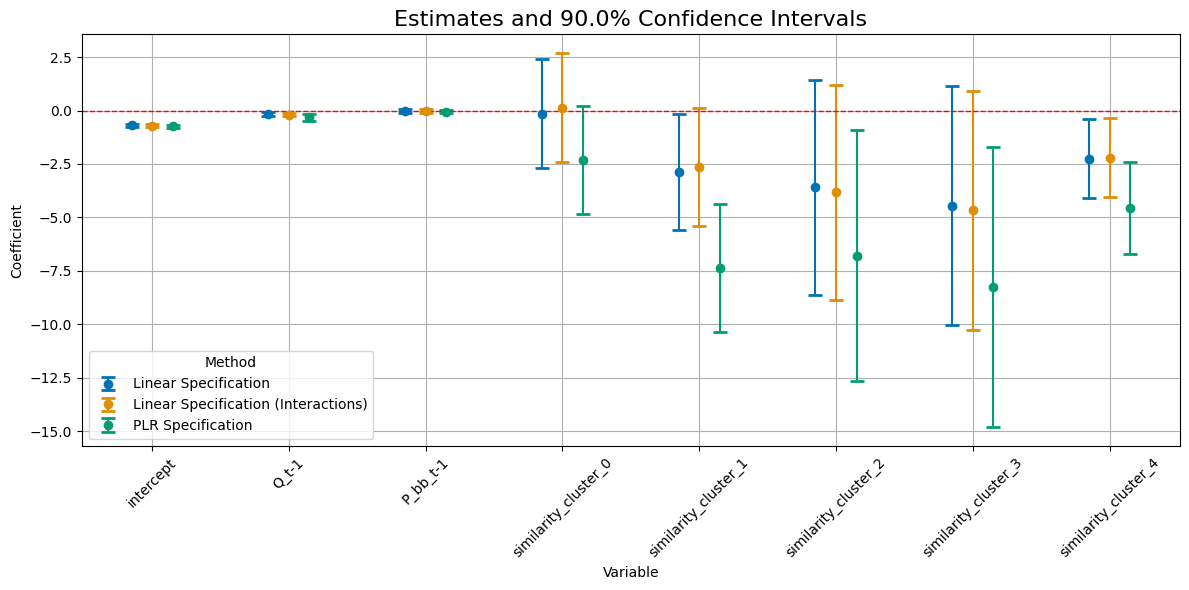

In [51]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### $R^2$

In [52]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial[
    "Linear Specification (Interactions)"
].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)


print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(
    alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_lvl = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[lag_1_vars])).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_lvl.rsquared)

print("Linear Specification with interactions")
model_lin_interactions_emb = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])
).fit()
model_lin_interactions_sim = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_interactions_lvl = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[lag_1_vars])
).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_interactions_lvl.rsquared)

print("PLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(
    alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_plr_lvl = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)
print("Variance explained by lagged variables: ", model_plr_lvl.rsquared)

Linear Specification
Variance explained by embeddings:  0.728303115175285
Variance explained by similarities:  0.6782509504690746
Variance explained by lagged variables:  0.7396255824897926
Linear Specification with interactions
Variance explained by embeddings:  0.6861223063312548
Variance explained by similarities:  0.6279801110201799
Variance explained by lagged variables:  0.7753125921646224
PLR Specification
Variance explained by embeddings:  0.5835124047901272
Variance explained by similarities:  0.5062094657968077
Variance explained by lagged variables:  0.7468357881193504


### Incremental $R^2$

In [53]:
r2_contributions_linear = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_lin, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_linear[col] = 1 - reduced_r2

print("R2 Contributions Linear:", r2_contributions_linear)

r2_contributions_linear_interactions = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_lin_interactions, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_linear_interactions[col] = 1 - reduced_r2

print("R2 Contributions Linear Interactions:", r2_contributions_linear_interactions)

r2_contributions_plr = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_plr, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_plr[col] = 1 - reduced_r2

print("R2 Contributions PLR:", r2_contributions_plr)

R2 Contributions Linear: {'intercept': np.float64(0.0), 'Q_t-1': np.float64(0.321312471600113), 'P_bb_t-1': np.float64(0.0017122616417157843), 'similarity_cluster_0': np.float64(0.00030957737638304117), 'similarity_cluster_1': np.float64(0.09065844894737163), 'similarity_cluster_2': np.float64(0.045031264158042705), 'similarity_cluster_3': np.float64(0.05529187201412333), 'similarity_cluster_4': np.float64(0.1240489662971731)}
R2 Contributions Linear Interactions: {'intercept': np.float64(0.0), 'Q_t-1': np.float64(0.3720140286265934), 'P_bb_t-1': np.float64(0.00479944007225841), 'similarity_cluster_0': np.float64(0.0002589976913062175), 'similarity_cluster_1': np.float64(0.07002542393989597), 'similarity_cluster_2': np.float64(0.046408117022919027), 'similarity_cluster_3': np.float64(0.05519197370418727), 'similarity_cluster_4': np.float64(0.10970425162503539)}
R2 Contributions PLR: {'intercept': np.float64(0.0), 'Q_t-1': np.float64(0.49364724404208427), 'P_bb_t-1': np.float64(0.007908

In [54]:
print(np.array([val for val in r2_contributions_linear.values()]).sum())
print(np.array([val for val in r2_contributions_linear_interactions.values()]).sum())
print(np.array([val for val in r2_contributions_plr.values()]).sum())

0.6383648620349226
0.6584022326821957
1.1139454922825154


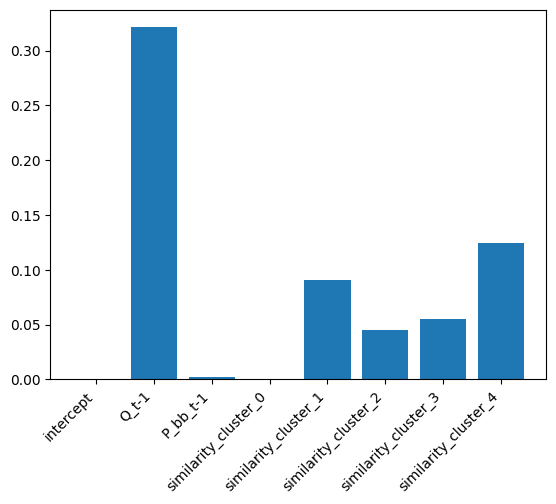

In [55]:
plt.bar(r2_contributions_linear.keys(), r2_contributions_linear.values())
plt.xticks(rotation=45, ha="right")
plt.show()

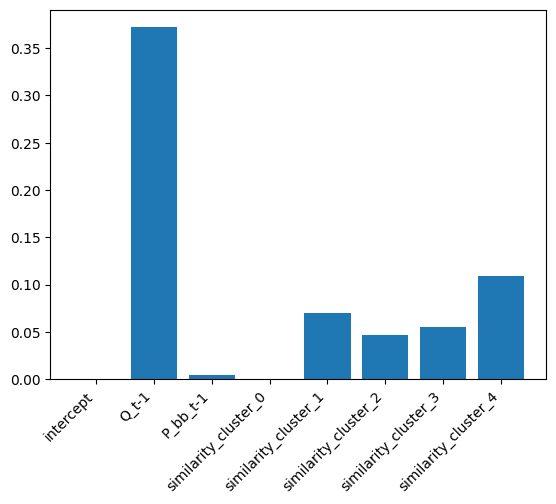

In [56]:
plt.bar(
    r2_contributions_linear_interactions.keys(),
    r2_contributions_linear_interactions.values(),
)
plt.xticks(rotation=45, ha="right")
plt.show()

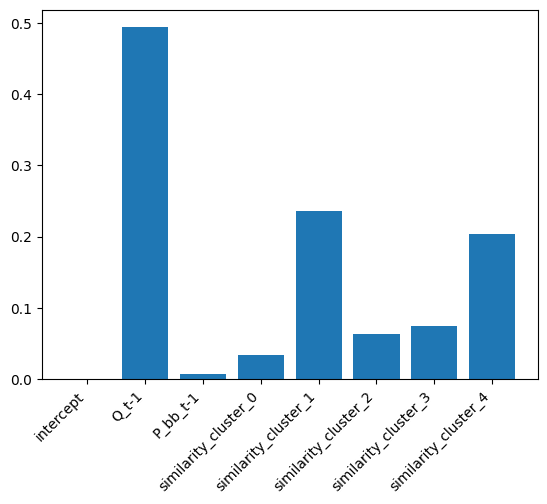

In [57]:
plt.bar(r2_contributions_plr.keys(), r2_contributions_plr.values())
plt.xticks(rotation=45, ha="right")
plt.show()

## $\Chi^2$ Test

In [58]:
# select index with cluster similarity
cluster_treatment_ids = [
    i for i, variable in enumerate(df_basis.columns) if "similarity_cluster" in variable
]
cluster_treatment_ids

[3, 4, 5, 6, 7]

In [59]:
lin_p_val = chi2_test(
    cate_models_polynomial["Linear Specification"], cluster_treatment_ids
)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial["PLR Specification"], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.02998417824688937 (sample size: 38041)
Linear Specification (Interactions) p-value: 0.0538828559161757 (sample size: 38041)
PLR Specification p-value: 0.0009061660603696398 (sample size: 38041)


In [60]:
het_ids = [1, 2, 3, 4, 5, 6, 7]

lin_p_val = chi2_test(cate_models_polynomial["Linear Specification"], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], het_ids
)
tab_dml_p_val = chi2_test(cate_models_polynomial["PLR Specification"], het_ids)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 5.046780121920058e-06 (sample size: 38041)
Linear Specification (Interactions) p-value: 3.7771242908934965e-06 (sample size: 38041)
PLR Specification p-value: 4.3235888869119776e-08 (sample size: 38041)


## Sorted Effects

In [61]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]  # .join(df_dynamic[["ASIN", "date"]])

In [62]:
df_basis_sorted

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,0.305280,0.463601,-0.461880,0.463422,0.457113,-0.620049,-0.080700
1,1.0,0.272505,0.653600,-0.461880,0.463422,0.457113,-0.620049,-0.080700
2,1.0,0.036240,0.687961,-0.461695,0.459950,0.457477,-0.622177,-0.072107
3,1.0,0.025283,0.636881,-0.461695,0.459950,0.457477,-0.622177,-0.072107
4,1.0,-0.051370,0.556816,-0.461695,0.459950,0.457477,-0.622177,-0.072107
...,...,...,...,...,...,...,...,...
38036,1.0,0.009068,0.478593,-0.079348,0.162986,0.069090,-0.088975,-0.156031
38037,1.0,-0.393270,-0.753352,0.395061,-0.460362,0.706488,-0.570121,0.486352
38038,1.0,-0.277916,-0.753352,0.381826,-0.444585,0.722214,-0.589989,0.487661
38039,1.0,1.267533,-1.535804,-0.386963,0.324396,0.753702,-0.877618,0.092195


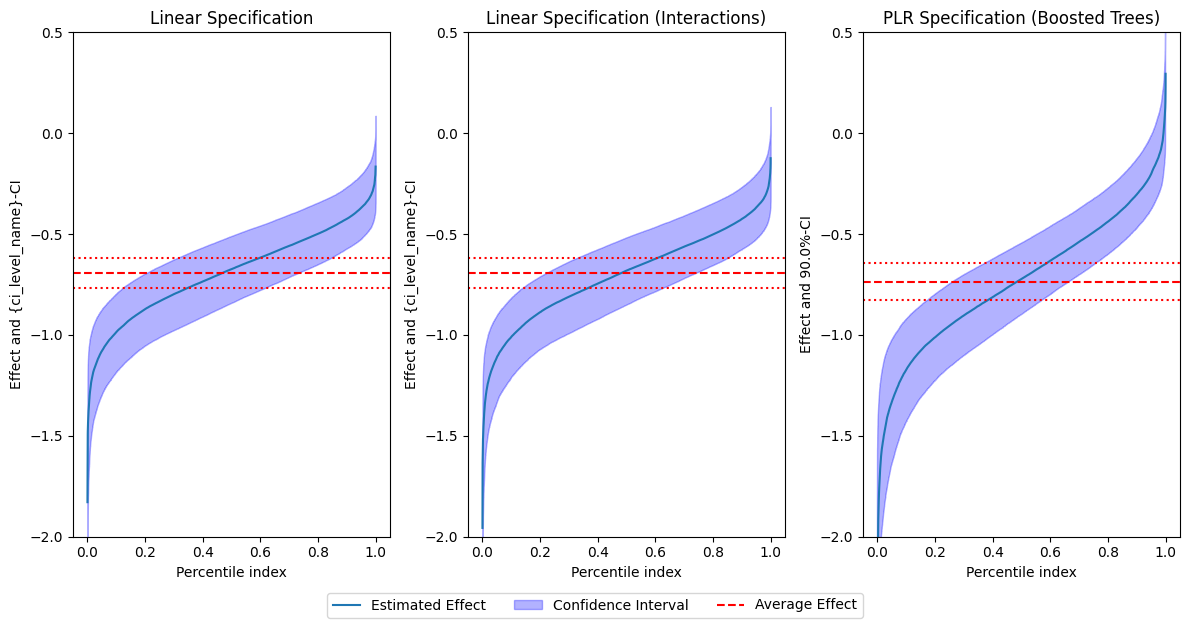

In [63]:
uniform_ci = False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial["PLR Specification"].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial["PLR Specification"].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -2)
y_max = min(y_max, 0.5)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel("Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel("Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(os.path.join(output_dir, "cluster_sorted_effects.png"), bbox_inches="tight")
plt.show()

In [64]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-1.32198408, -1.23329557, -1.18107363, -1.14354946, -1.11162049,
       -1.08522233, -1.06420504, -1.04394366, -1.02580337, -1.010058  ,
       -0.99492252, -0.9809761 , -0.96792875, -0.95406243, -0.94057512,
       -0.92905576, -0.91823026, -0.90750734, -0.8977652 , -0.88753871,
       -0.87758667, -0.86897235, -0.86121569, -0.85330791, -0.84592225,
       -0.83842537, -0.83196603, -0.82447797, -0.81769153, -0.81052953,
       -0.80418167, -0.79749779, -0.79125086, -0.78497899, -0.77833915,
       -0.77198144, -0.76559575, -0.75877775, -0.75193425, -0.74561754,
       -0.73924165, -0.73294451, -0.72633099, -0.72032155, -0.71418683,
       -0.70691883, -0.70074403, -0.69422087, -0.6879893 , -0.68128868,
       -0.67500074, -0.66946448, -0.66334161, -0.65798933, -0.65221556,
       -0.64645205, -0.6404376 , -0.63490947, -0.62878975, -0.62294119,
       -0.6172833 , -0.61122978, -0.60546322, -0.59920371, -0.59288032,
       -0.58729722, -0.58142857, -0.57540835, -0.56929716, -0.56

In [65]:
from scipy.stats import norm

alpha = 0.1
Y_tilde, D_tilde = plr_obj._partial_out()
n = len(df_dynamic)
B = 500
rng = np.random.default_rng(42)

spes_mat = np.full((m, B), fill_value=np.nan)

for b in range(B):
    sample_indices = rng.choice(n, size=n, replace=True)
    Y_b = Y_tilde[sample_indices]
    D_b = D_tilde[sample_indices]
    psi_D_b = df_basis.values * D_b.reshape(-1, 1)
    model_b = sm.OLS(Y_b, psi_D_b).fit()
    beta_b = model_b.params
    pes_b = beta_b.T @ df_basis.values.T
    spes_mat[:, b] = np.quantile(pes_b, quantiles)


Z_mat = np.sqrt(n) * (spes_mat - spes.reshape(-1, 1))
iqr_norm = norm.ppf(0.75) - norm.ppf(0.25)
iqr_emp = np.quantile(Z_mat, 0.75, axis=1) - np.quantile(Z_mat, 0.25, axis=1)
Sigma_u = iqr_emp / iqr_norm

t = np.max((np.abs(Z_mat) / Sigma_u.reshape(-1, 1)), axis=0)
t_quant = np.quantile(t, 1 - alpha)

spes_boot_cis = pd.DataFrame(
    {
        "quantiles": quantiles,
        "lower": spes - (t_quant / np.sqrt(n)) * Sigma_u,
        "effect": spes,
        "upper": spes + (t_quant / np.sqrt(n)) * Sigma_u,
    }
)
spes_boot_cis

,quantiles,lower,effect,upper
0,0.01,-1.840844,-1.321984,-0.803125
1,0.02,-1.700778,-1.233296,-0.765813
2,0.03,-1.604851,-1.181074,-0.757297
3,0.04,-1.556250,-1.143549,-0.730849
4,0.05,-1.514764,-1.111620,-0.708477
...,...,...,...,...
94,0.95,-0.740222,-0.368889,0.002444
95,0.96,-0.738641,-0.353088,0.032465
96,0.97,-0.750520,-0.336731,0.077057
97,0.98,-0.753510,-0.314111,0.125288


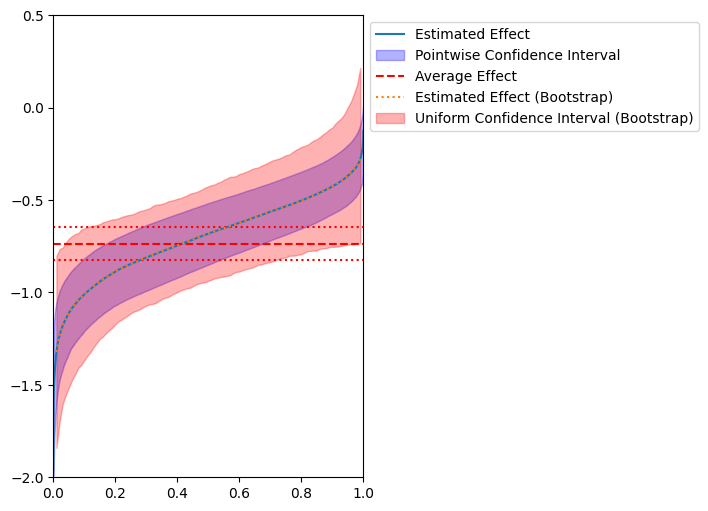

In [66]:
plt.figure(figsize=(4, 6))

plt.plot(
    percentiles_idx_full,
    df_tab_dml_ci_joint_sorted["effect"],
    label="Estimated Effect",
)
plt.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Pointwise Confidence Interval",
)
if uniform_ci:
    plt.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
plt.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
plt.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
plt.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

plt.plot(
    spes_boot_cis["quantiles"],
    spes_boot_cis["effect"],
    label="Estimated Effect (Bootstrap)",
    linestyle="dotted",
)
plt.fill_between(
    spes_boot_cis["quantiles"].sort_values(),
    spes_boot_cis["lower"].sort_values(),
    spes_boot_cis["upper"].sort_values(),
    color="red",
    alpha=0.3,
    label="Uniform Confidence Interval (Bootstrap)",
)

plt.xlim(0, 1)
plt.legend(loc="best", bbox_to_anchor=(1, 1))
plt.ylim(-2, 0.5)
# plt.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="ATE")
plt.show()

In [67]:
alpha = 0.1
# Assuming the partial out function returns (Y_tilde, D_tilde)
Y_tilde, D_tilde = plr_obj._partial_out()
n = len(df_dynamic)

# Define bootstrap parameters and quantile levels
B = 1000
rng = np.random.default_rng(42)
quantiles = np.arange(start=0.2, stop=0.81, step=0.01)
m = len(quantiles)

# Compute the original quantile estimates (spes) from your base model
# (This assumes you have a way to get the original model predictions)
original_model = sm.OLS(Y_tilde, D_tilde).fit()
pes_original = original_model.predict(D_tilde)
spes = np.quantile(pes_original, quantiles)

spes_mat = np.full((m, B), fill_value=np.nan)

for b in range(B):
    sample_indices = rng.choice(n, size=n, replace=True)
    Y_b = Y_tilde[sample_indices]
    D_b = D_tilde[sample_indices]
    model_b = sm.OLS(Y_b, D_b).fit()
    pes_b = model_b.predict(D_tilde)
    spes_mat[:, b] = np.quantile(pes_b, quantiles)

Z_mat = np.sqrt(n) * (spes_mat - spes.reshape(-1, 1))
iqr_norm = norm.ppf(0.75) - norm.ppf(0.25)
iqr_emp = np.quantile(Z_mat, 0.75, axis=1) - np.quantile(Z_mat, 0.25, axis=1)
Sigma_u = iqr_emp / iqr_norm

# Compute t statistics for each bootstrap replication
t = np.max(np.abs(Z_mat) / Sigma_u.reshape(-1, 1), axis=0)
t_quant = np.quantile(t, 1 - alpha)

spes_boot_cis = pd.DataFrame(
    {
        "lower": spes - (t_quant / np.sqrt(n)) * Sigma_u,
        "effect": spes,
        "upper": spes + (t_quant / np.sqrt(n)) * Sigma_u,
    }
)
spes_boot_cis

,lower,effect,upper
0,-0.031847,-0.029568,-0.027289
1,-0.029955,-0.027811,-0.025668
2,-0.028031,-0.026025,-0.024019
3,-0.026302,-0.024420,-0.022538
4,-0.024524,-0.022769,-0.021014
...,...,...,...
57,0.022561,0.024445,0.026329
58,0.024138,0.026153,0.028169
59,0.025836,0.027993,0.030150
60,0.027586,0.029889,0.032193


In [68]:
df_effects = df_dynamic[["ASIN", "date"]].copy()

df_effects["SortEff_lin"] = df_lin_ci_pointwise["effect"]
df_effects["SortEff_tab_dml"] = df_tab_dml_ci_pointwise["effect"]
df_effects["SortEff_deep_dml"] = df_deep_dml_ci_pointwise["effect"]

df_effects.to_csv(os.path.join(output_dir, "sorted_effects.csv"), index=False)

## Heterogeneity on PCA Components

In [69]:
eigenRes = np.linalg.eig(df_full_val[[f"emb_{i}" for i in range(256)]].cov())

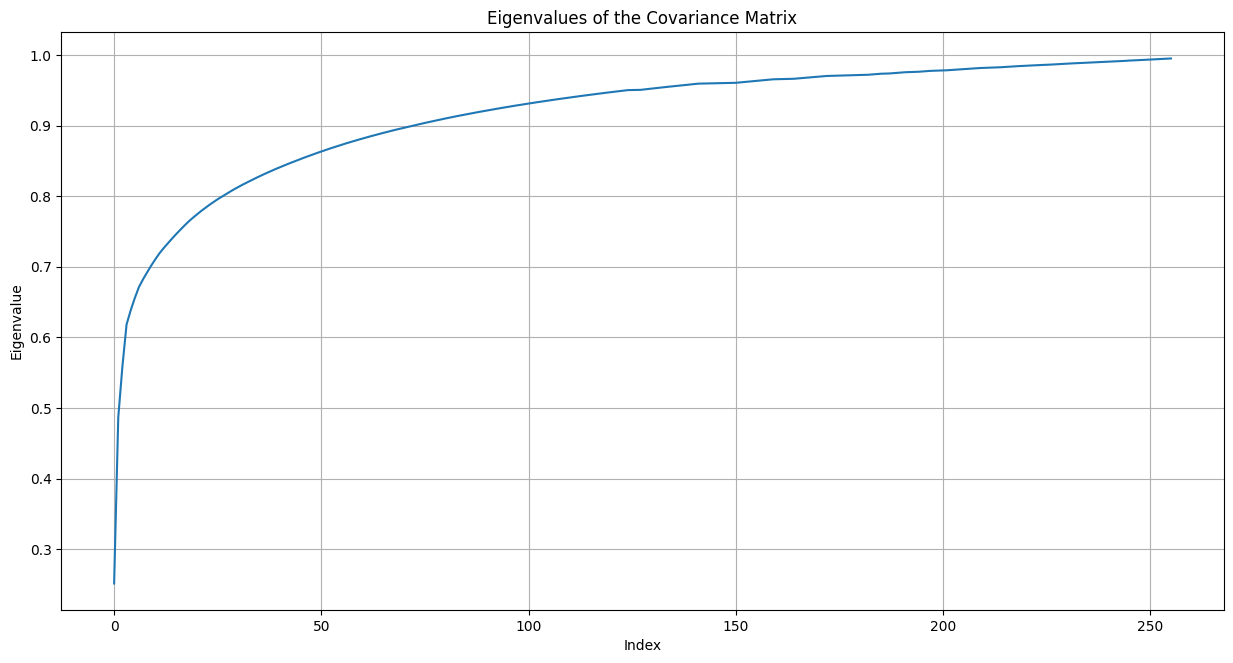

In [70]:
plt.plot(np.cumsum(eigenRes.eigenvalues), label="Cumulative Sum of Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
# plt.xscale("log")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

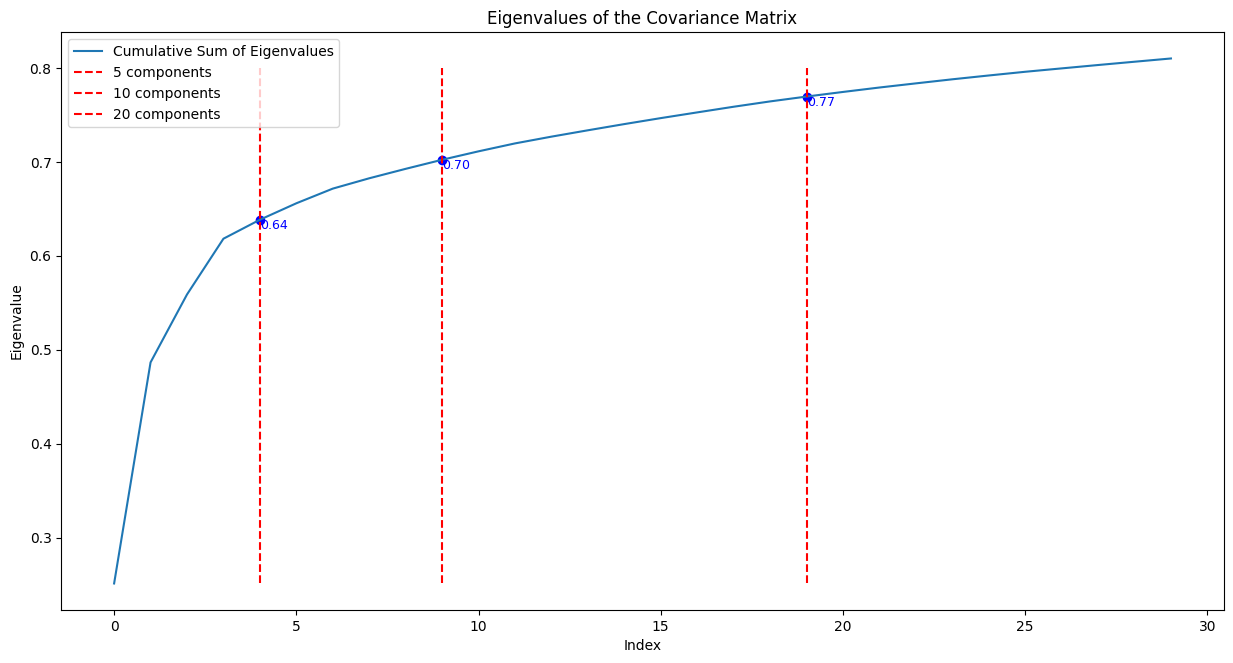

In [71]:
max_eig = 30

# Calculate cumulative sum of eigenvalues
cumsum_eigenvalues = np.cumsum(eigenRes.eigenvalues[:max_eig])

# Plot the cumulative sum of eigenvalues
plt.plot(cumsum_eigenvalues, label="Cumulative Sum of Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

# Mark vertical lines and annotate intersection points
components = [5, 10, 20]
for comp in components:
    y_value = cumsum_eigenvalues[
        comp - 1
    ]  # Get the y-axis value at the component index
    plt.vlines(
        x=comp - 1,
        ymin=cumsum_eigenvalues[0],
        ymax=0.8,
        color="r",
        linestyle="--",
        label=f"{comp} components",
    )
    plt.scatter(comp - 1, y_value, color="blue")  # Mark the intersection point
    plt.text(
        comp - 1 + 0.01, y_value - 0.01, f"{y_value:.2f}", color="blue", fontsize=9
    )  # Annotate the point

plt.legend()
plt.show()

In [72]:
print(len(df_full_val))

38041


In [73]:
from sklearn.decomposition import PCA

pca_05 = PCA(n_components=5, random_state=42)
pca_10 = PCA(n_components=10, random_state=42)
pca_20 = PCA(n_components=20, random_state=42)

pca_05_results = pca_05.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_10_results = pca_10.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_20_results = pca_20.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_05_results.shape, pca_10_results.shape, pca_20_results.shape

((38041, 5), (38041, 10), (38041, 20))

In [74]:
pca_05_vars = [f"pca_05_{i}" for i in range(5)]
pca_10_vars = [f"pca_10_{i}" for i in range(10)]
pca_20_vars = [f"pca_20_{i}" for i in range(20)]

df_val_pca_05 = pd.DataFrame(pca_05_results, columns=pca_05_vars)
df_val_pca_10 = pd.DataFrame(pca_10_results, columns=pca_10_vars)
df_val_pca_20 = pd.DataFrame(pca_20_results, columns=pca_20_vars)
df_val_pca = pd.concat(
    [df_full_val.reset_index(), df_val_pca_05, df_val_pca_10, df_val_pca_20], axis=1
)

df_val_pca.shape

(38041, 378)

In [75]:
n_pcas = ["5", "10", "20"]
df_dynamic = df_val_pca.copy()

cate_kwargs_val = {
    f"pca_{n}_components": {
        "cov_type": "cluster",
        "cov_kwds": {"groups": df_dynamic["ASIN"]},
    }
    for n in n_pcas
}

cate_models_polynomial = {
    f"pca_{n}_components": {
        "Linear Specification": None,
        "Linear Specification (Interactions)": None,
        "PLR Specification": None,
    }
    for n in n_pcas
}

for pca_conf, pca_vars in zip(n_pcas, [pca_05_vars, pca_10_vars, pca_20_vars]):
    basis_vars = pca_vars + lag_1_vars
    df_basis, column_transformer, column_dict = generate_basis(
        df=df_dynamic, cols_without_scaling=pca_vars, cols_to_scale=lag_1_vars, degree=1
    )
    df_interact_val, interaction_vars = generate_interactions(
        df=df_dynamic, df_basis=df_basis, cols_to_interact=lag_1_vars
    )

    cate_controls = lag_1_vars + embeddings + additional_controls
    cate_controls_interactions = cate_controls + interaction_vars

    plr_obj = tab_dml_obj_embeddings_add_controls

    # Linear Models
    cate_models_polynomial[f"pca_{pca_conf}_components"]["Linear Specification"] = (
        lin_model_cate(
            df=df_dynamic,
            outcome=outcome,
            basis=df_basis,
            treatment=base_treatment,
            controls=cate_controls,
            **cate_kwargs_val,
        )
    )

    print(f"\nLinear Specification")
    df_specification_1 = summarize_lin_model(
        cate_models_polynomial[f"pca_{pca_conf}_components"]["Linear Specification"],
        level=confidence_level,
    )
    print("=" * 80)  #

    cate_models_polynomial[f"pca_{pca_conf}_components"][
        "Linear Specification (Interactions)"
    ] = lin_model_cate(
        df=df_interact_val,
        outcome=outcome,
        basis=df_basis,
        treatment=base_treatment,
        controls=cate_controls_interactions,
        **cate_kwargs_val,
    )

    print(f"\nLinear specification with interactions")
    df_specification_2 = summarize_lin_model(
        cate_models_polynomial[f"pca_{pca_conf}_components"][
            "Linear Specification (Interactions)"
        ],
        level=confidence_level,
    )
    print("=" * 80)

    # tabular DML model
    cate_models_polynomial[f"pca_{pca_conf}_components"]["PLR Specification"] = (
        plr_obj.cate(df_basis, **cate_kwargs_val)
    )

    print(f"\nTabular DML PLR Specification")
    df_specification_3 = summarize_lin_model(
        cate_models_polynomial[f"pca_{pca_conf}_components"][
            "PLR Specification"
        ].blp_model,
        level=confidence_level,
    )
    print("=" * 80)


Linear Specification
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.694    0.036 -19.143  0.000 -0.753 -0.634
Q_t-1     -0.160    0.052  -3.042  0.002 -0.246 -0.073
P_bb_t-1  -0.012    0.047  -0.246  0.806 -0.090  0.066
pca_05_0  -0.072    0.099  -0.722  0.470 -0.235  0.092
pca_05_1   0.023    0.101   0.229  0.819 -0.143  0.189
pca_05_2   0.297    0.135   2.205  0.027  0.076  0.519
pca_05_3   0.097    0.141   0.683  0.495 -0.136  0.329
pca_05_4   0.278    0.210   1.325  0.185 -0.067  0.623

Linear specification with interactions
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.701    0.036 -19.296  0.000 -0.760 -0.641
Q_t-1     -0.179    0.052  -3.422  0.001 -0.264 -0.093
P_bb_t-1  -0.020    0.048  -0.420  0.675 -0.100  0.059
pca_05_0  -0.049    0.100  -0.495  0.620 -0.213  0.115
pca_05_1   0.021    0.102   0.208  0.835 -0.146  0.188
pca_05_2   0.315    0.135   2.324  0.020  0.092  0.537
pca_05_3   0.073    0.143   0.513  0.608 -0.161  0.308
pca

In [76]:
cate_summary_dfs_pca = {f"pca_{n}_components": [] for n in n_pcas}
summary_list = []

for pca_conf in n_pcas:
    summary_list = []
    for model_name, model in cate_models_polynomial[
        f"pca_{pca_conf}_components"
    ].items():
        if "Linear" in model_name:
            tmp_summary = summarize_lin_model(model, level=confidence_level)
        else:
            tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
        for index, row in tmp_summary.iterrows():
            variable = index
            summary_list.append(
                {
                    "model": model_name,
                    "variable": variable,
                    "coef": row["coef"],
                    "Std.Err.": row["std err"],
                    "lower": row[ci_names[0]],  # Adjusted to match the column name
                    "upper": row[ci_names[1]],  # Adjusted to match the column name
                }
            )

    cate_summary_dfs_pca[f"pca_{pca_conf}_components"] = pd.DataFrame(summary_list)

            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.694    0.036 -19.143  0.000 -0.753 -0.634
Q_t-1     -0.160    0.052  -3.042  0.002 -0.246 -0.073
P_bb_t-1  -0.012    0.047  -0.246  0.806 -0.090  0.066
pca_05_0  -0.072    0.099  -0.722  0.470 -0.235  0.092
pca_05_1   0.023    0.101   0.229  0.819 -0.143  0.189
pca_05_2   0.297    0.135   2.205  0.027  0.076  0.519
pca_05_3   0.097    0.141   0.683  0.495 -0.136  0.329
pca_05_4   0.278    0.210   1.325  0.185 -0.067  0.623
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.701    0.036 -19.296  0.000 -0.760 -0.641
Q_t-1     -0.179    0.052  -3.422  0.001 -0.264 -0.093
P_bb_t-1  -0.020    0.048  -0.420  0.675 -0.100  0.059
pca_05_0  -0.049    0.100  -0.495  0.620 -0.213  0.115
pca_05_1   0.021    0.102   0.208  0.835 -0.146  0.188
pca_05_2   0.315    0.135   2.324  0.020  0.092  0.537
pca_05_3   0.073    0.143   0.513  0.608 -0.161  0.308
pca_05_4   0.243    0.211   1.156  0.248 -0.103  0.590
          

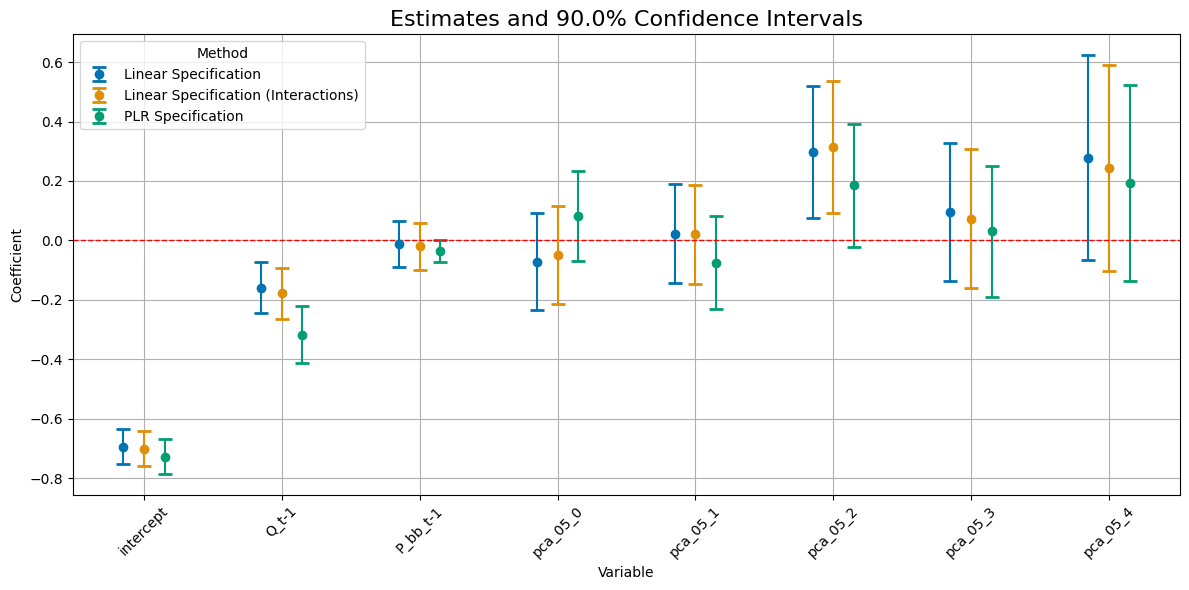

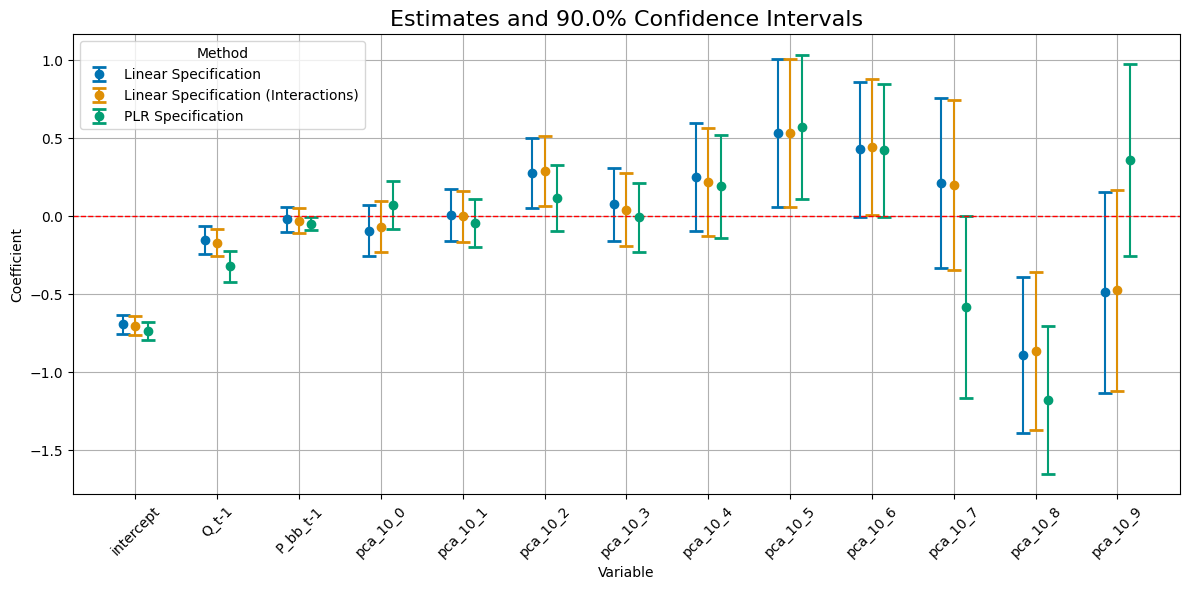

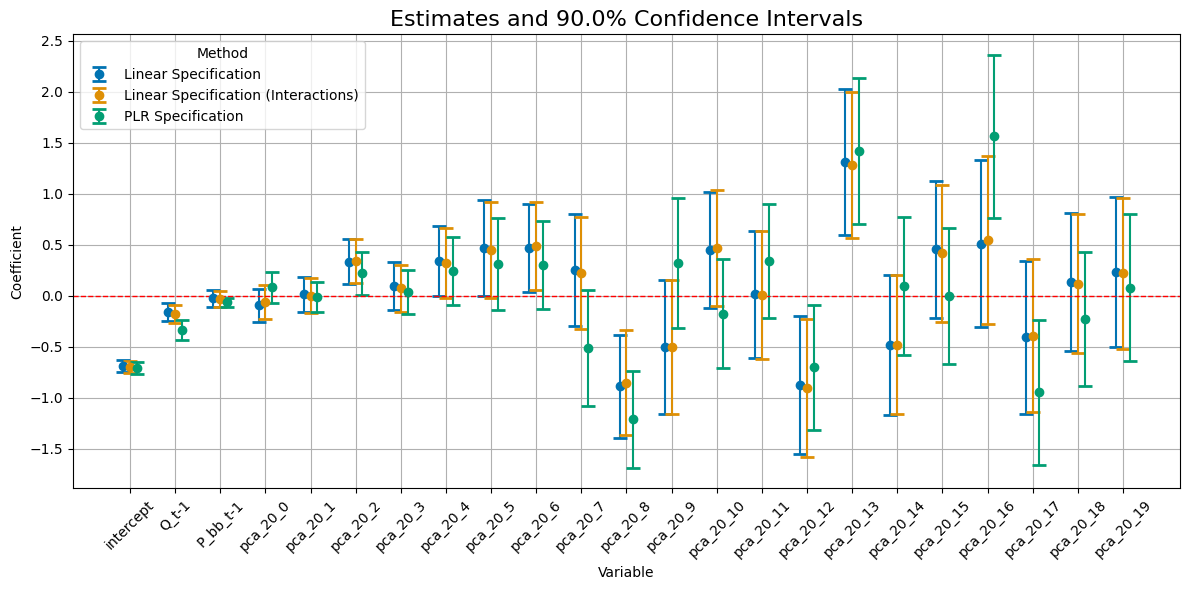

In [77]:
for cate_summary_df in cate_summary_dfs_pca.values():
    models = cate_summary_df["model"].unique()
    variables = cate_summary_df["variable"].unique()
    plt.figure(figsize=(12, 6))
    bar_width = 0.15
    x_positions = np.arange(len(variables))
    for i, model in enumerate(models):
        df_model = cate_summary_df[cate_summary_df["model"] == model]
        if not df_model.empty:
            plt.errorbar(
                x_positions + i * bar_width,
                df_model["coef"],
                yerr=[
                    df_model["coef"] - df_model["lower"],
                    df_model["upper"] - df_model["coef"],
                ],
                fmt="o",
                label=model,
                capsize=5,
                capthick=2,
                ecolor=palette[i % len(palette)],
                color=palette[i % len(palette)],
                zorder=2,
            )
    plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
    plt.xlabel("Variable")
    plt.ylabel("Coefficient")
    plt.legend(title="Method")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"pca_and_level_cate_estimates.png"))
    plt.show()

In [78]:
def plot_sorted_func(cate_models_polynomial, pca_vars):
    basis_vars = pca_vars + lag_1_vars
    df_basis, _, _ = generate_basis(
        df=df_dynamic, cols_without_scaling=pca_vars, cols_to_scale=lag_1_vars, degree=1
    )
    cluster_treatment_ids = [
        i for i, variable in enumerate(df_basis.columns) if variable in pca_vars
    ]
    treatment_ids = [0, 1, 2] + cluster_treatment_ids
    df_basis_sorted = df_basis.iloc[:, treatment_ids]
    plt.rcParams["figure.figsize"] = (
        15.0,
        7.5,
    )  # Adjusted the figure size for side-by-side plots
    # Determine the number of models to plot
    num_plots = 1
    # Create subplots with cate_vars as rows and models as columns
    fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
    # If there's only one model, axs won't be a list, so wrap it in a list
    if num_plots == 1:
        axs = np.array([axs, axs])  # Create a 2-column array

    # Linear model
    df_lin_ci_pointwise = predict_cate(
        cate_models_polynomial["Linear Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_lin_ci_uniform = predict_cate(
        cate_models_polynomial["Linear Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
        lambda x: x.sort_values().values, axis=0
    )
    lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
    lm_intercept_ci = (
        cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
    )

    # Tabular DML model
    df_tab_dml_ci_pointwise = predict_cate(
        cate_models_polynomial["Linear Specification (Interactions)"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_tab_dml_ci_joint = predict_cate(
        cate_models_polynomial["Linear Specification (Interactions)"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
        lambda x: x.sort_values().values, axis=0
    )

    tab_dml_intercept = cate_models_polynomial["Linear Specification"].params[
        "intercept"
    ]
    tab_dml_intercept_ci = (
        cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
    )

    # PLR Model
    df_deep_dml_ci_pointwise = predict_cate(
        cate_models_polynomial["PLR Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_deep_dml_ci_joint = predict_cate(
        cate_models_polynomial["PLR Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
        lambda x: x.sort_values().values, axis=0
    )
    deep_dml_intercept = cate_models_polynomial["PLR Specification"].blp_model.params[
        "intercept"
    ]
    deep_dml_intercept_ci = (
        cate_models_polynomial["PLR Specification"]
        .blp_model.conf_int()
        .loc["intercept"]
    )

    # Calculate the y-axis limits for this row
    y_min = min(
        df_lin_ci_pointwise[ci_names[0]].min(),
        df_lin_ci_uniform[ci_names[0]].min(),
        df_tab_dml_ci_pointwise[ci_names[0]].min(),
        df_tab_dml_ci_joint[ci_names[0]].min(),
        df_deep_dml_ci_pointwise[ci_names[0]].min(),
        df_deep_dml_ci_joint[ci_names[0]].min(),
    )
    y_max = max(
        df_lin_ci_pointwise[ci_names[1]].max(),
        df_lin_ci_uniform[ci_names[1]].max(),
        df_tab_dml_ci_pointwise[ci_names[1]].max(),
        df_tab_dml_ci_joint[ci_names[1]].max(),
        df_deep_dml_ci_pointwise[ci_names[1]].max(),
        df_deep_dml_ci_joint[ci_names[1]].max(),
    )

    # further adjust y-axis limits
    y_min = max(y_min, -1.75)
    y_max = min(y_max, 0.0)
    percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
    percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
    # Plot on the first column
    i = 0
    ax0 = axs[i, 0]
    ax0.plot(
        percentiles_idx_full,
        df_lin_ci_pointwise_sorted["effect"],
        label="Estimated Effect",
    )
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_pointwise_sorted[ci_names[0]],
        df_lin_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax0.fill_between(
            percentiles_idx_full,
            df_lin_ci_uniform_sorted[ci_names[0]],
            df_lin_ci_uniform_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
    ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
    ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
    ax0.set_title(f"Linear Specification")
    ax0.set_xlabel("Percentile index")
    ax0.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax0.set_ylim(y_min, y_max)
    ax1 = axs[i, 1]
    ax1.plot(
        percentiles_idx_full,
        df_tab_dml_ci_pointwise_sorted["effect"],
        label="Estimated Effect",
    )
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_pointwise_sorted[ci_names[0]],
        df_tab_dml_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax1.fill_between(
            percentiles_idx_full,
            df_tab_dml_ci_joint_sorted[ci_names[0]],
            df_tab_dml_ci_joint_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
    ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
    ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
    ax1.set_title(f"Linear Specification (Interactions)")
    ax1.set_xlabel("Percentile index")
    ax1.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax1.set_ylim(y_min, y_max)

    ax2 = axs[i, 2]
    ax2.plot(
        percentiles_idx_full,
        df_deep_dml_ci_pointwise_sorted["effect"],
        label="Estimated Effect",
    )
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_pointwise_sorted[ci_names[0]],
        df_deep_dml_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax2.fill_between(
            percentiles_idx_full,
            df_deep_dml_ci_joint_sorted[ci_names[0]],
            df_deep_dml_ci_joint_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
    ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
    ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

    ax2.set_title("PLR Specification (Boosted Trees)")
    ax2.set_xlabel("Percentile index")
    ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax2.set_ylim(y_min, y_max)

    # Create a single legend for all plots and place it at the lower center
    handles, labels = axs[
        -1, 1
    ].get_legend_handles_labels()  # Collect handles and labels from the last subplot
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
    # Adjust layout to make space for the legend
    plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

    # Save the figure with tight bounding box to include the legend
    plt.savefig(os.path.join(output_dir, "pca_sorted_effects.png"), bbox_inches="tight")
    plt.show()

Sorted Effects for pca_5_components


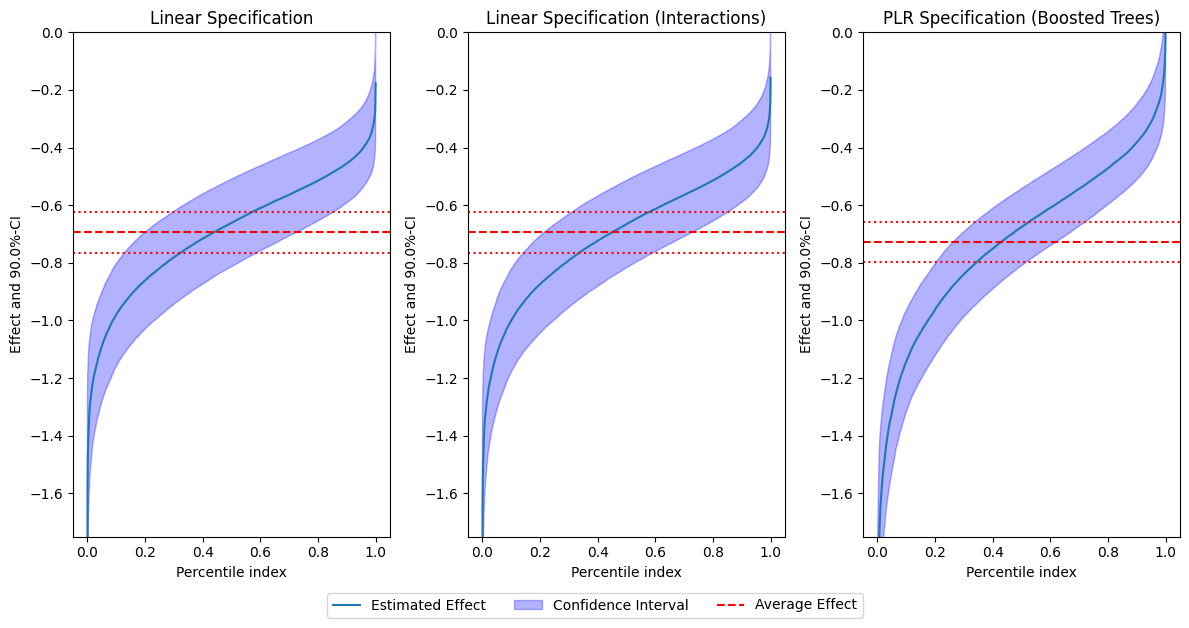

Sorted Effects for pca_10_components


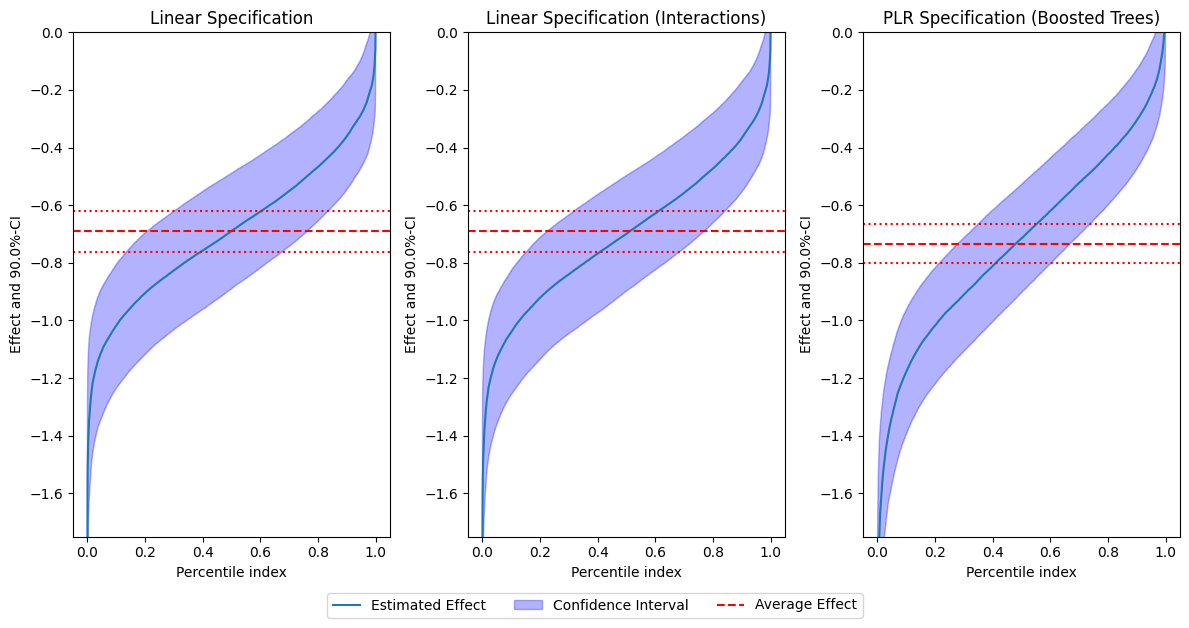

Sorted Effects for pca_20_components


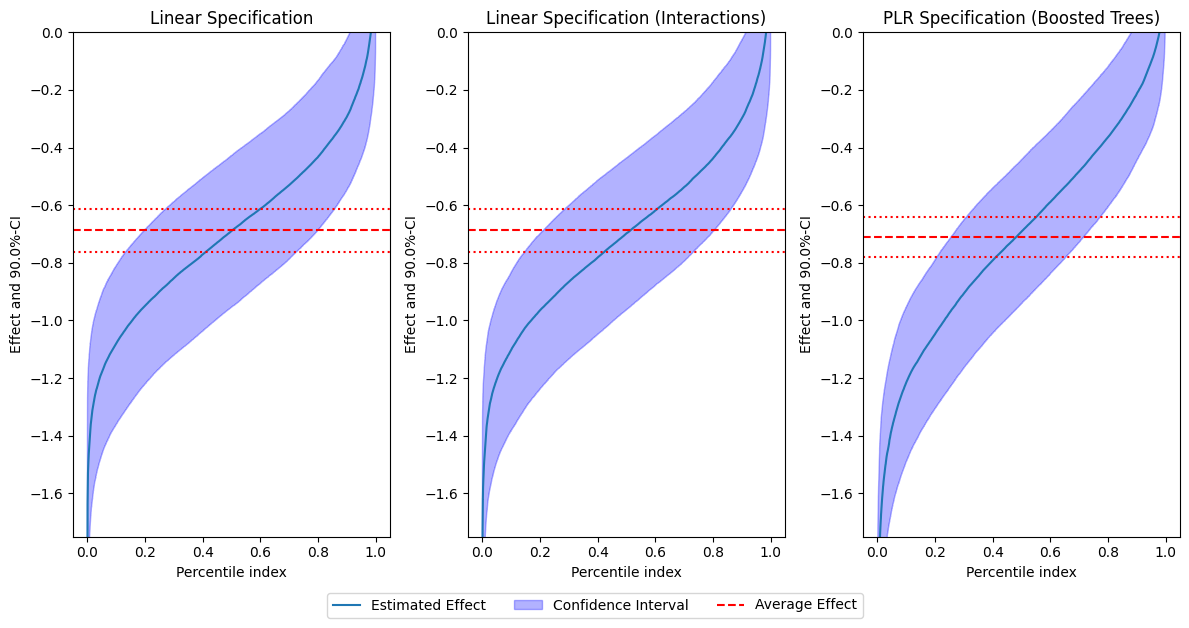

In [79]:
for (nme, cate_models_polynomial_i), pca_vars_i in zip(
    cate_models_polynomial.items(), [pca_05_vars, pca_10_vars, pca_20_vars]
):
    print(f"Sorted Effects for {nme}")
    plot_sorted_func(cate_models_polynomial_i, pca_vars_i)